### $\color{indianred}{\text{ASTROSTATISTIKA - v8}} $

<hr style="border: none; height: 2px; background-color: indianred; opacity: 0.5;" />

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, poisson, cauchy
from scipy.stats import kstwo, kstest, ks_2samp
from scipy.integrate import quad
import matplotlib
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

Važno je na neki način kvantifikovati slaganje između datog skupa uzoraka i modela/hipoteze. Ukoliko je npr. $\{x_i\}$ izvučen iz $\mathcal{N}(\mu,\sigma)$ raspodjele, onda je $\mathcal{N}(\mu,\sigma)$ 

nulta hipoteza (koja obično odgovara odsustvu nekog efekta), koju treba odbaciti da bi se izmjerio neki efekat.

$\blacksquare$ **P1**: Nakon pregleda astronomskih snimaka, uočava se slab objekat koji se pojavljuje na istoj poziciji - nejasno je da li je u pitanju šum. U cilju testiranja hipoteze, 

pravimo više snimaka tokom više noći.

- *Nulta hipoteza*: izmjereni sjaj objekta potiče od pozadinskog šuma - ako je odbacimo, detektovali smo izvor;

- *Alternativna hipoteza*: u snimku postoji pravi tačkasti izvor;

- Doprinos fluksa izvora mora biti znatno veći od fluktuacija pozadine da bi detekcija bila pouzdana.

Uvodimo tzv. $p$-vrijednost - vjerovatnoću da su dobijeni podaci nastali pod pretpostavkom da je nulta hipoteza tačna. Što je $p$-vrijednost manja, to je
alternativna

 hipoteza vjerovatnija. Uobičajeno se usvaja granična $p$-vrijednost zvana *nivo značajnosti* $\alpha$, i odbacujemo nultu hipotezu kada je $p \leq \alpha$.

$\blacksquare$ **P2**: Bacamo novčić osam puta i dobijamo šest pisama - treba li odbaciti hipotezu da je novčić *pošten*? Donosimo nultu hipotezu da jeste pošten.
Vjerovatnoće za

svaki od ishoda nalazimo binomnom raspodjelom:

$$
p(k|b, N) = \frac{N!}{k!(N-k)!} b^k (1-b)^{N-k}.
$$

Pošto je $p$-vrijednost vjerovatnoća da se dogodi nešto *bar toliko ekstremno* kao naši podaci (uz pretpostavku nulte hipoteze), sabiramo vjerovatnoće za $6/8$, $7/8$

i $8/8$ pisama:

$$
p=\frac{8!}{6!2!}\frac{1}{2}^6\frac{1}{2}^2 + \frac{8!}{7!1!}\frac{1}{2}^7\frac{1}{2}^1 + \frac{8!}{8!0!}\frac{1}{2}^8\frac{1}{2}^0=0.145.
$$

Dobijena $p$-vrijednost je $0.145$, što znači da nultu hipotezu ne možemo odbaciti na nivou značajnosti $\alpha = 0.05$.

Prilikom sprovođenja testova, pojavljuju se dva tipa greški:

- tip I: slučajevi gdje nulta hipoteza jeste tačna, ali je nepravilno odbačena (*lažno pozitivni*);

- tip II: slučajevi gdje nulta hipoteza jeste netačna, ali je prihvaćena (*lažno negativni*).

Smanjenjem vrijednosti $\alpha$ broj LP se smanjuje, a broj LN se povećava - potrebno je naći optimalnu vrijednost za $\alpha$.

---

Uobičajeno je da je raspodjela $h(x)$ iz koje su podaci $\{x_i\}$ izvučeni *suma* dvije populacije:

$$
h(x) = (1-a)\, h_B(x) + a\, h_S(x)
$$

gdje je $a$ relativni faktor normalizacije. Nulta hipoteza odgovara pozadini ($B$), a alternativna izvoru ($S$). Svakom mjerenju $x_i$ dodjeljujemo vjerovatnoću $p_S(x_i)$ da 

pripada populaciji $S$, pri čemu je $p_B(x_i) = 1 - p_S(x_i)$. Veličina uzorka je $N$, a broj pravih izvora $Na$. Pojednostavljena verzija ovog problema jeste klasifikacija,

gdje se svakom $x_i$ dodjeljuje klasa $S$ ili $B$, bez zadržavanja same vjerovatnoće $p_S$. Da bi klasifikacija bila moguća, $h_B(x)$ i $h_S(x)$ moraju biti različite.
Za graničnu

 vrijednost $x_c$, broj LP (greška tipa I) i LN (greška tipa II) je:

$$
n_{\text{fp}} = N(1-a)\int_{x_c}^{\infty} h_B(x)\,dx \equiv N(1-a)\alpha,
$$

$$
n_{\text{fn}} = Na\int_0^{x_c} h_S(x)\,dx \equiv Na\beta.
$$

Ukupan broj instanci klasifikovanih kao izvor (nulta hipoteza je odbačena) dat je kao:

$$
n_{\text{s}} = Na - n_{\text{fn}} + n_{\text{fp}}.
$$

Tzv. potpunost uzorka ($0 \leq \eta \leq 1$) i *kontaminacija* tj. stopa lažnih otkrića (eng. *False Discovery Rate* - FDR) ($0 \leq \epsilon \leq 1$) definisane su kao:

$$
\eta = \frac{Na - n_{\text{fn}}}{Na} = 1 - \int_0^{x_c} h_S(x)\,dx, \qquad \epsilon = \frac{n_{\text{fp}}}{n_{\text{s}}}.
$$

Kako $x_c$ raste, kontaminacija opada, ali opada i potpunost - klasičan kompromis koji se vizualizuje ROC krivom (udio pravih pozitivnih i udio lažnih negativnih; eng.

 *Receiver Operating Characteristi*). Površina ispod ROC krive, tzv. $c$-statistika, mjeri ukupan kvalitet klasifikacije.

<hr style="border: none; height: 2px; background-color: magenta; opacity: 0.5;" />

$\color{magenta}{\text{Z1}}$ :  Neka je $h_B = \mathcal{N}(100, 10)$, $h_S = \mathcal{N}(150, 12)$, $a = 0.1$, $N = 10^6$. Za $x_c = 120$ ($2\sigma$ od srednje vrijednosti $h_B$, što odgovara greški tipa I sa $\alpha = 0.024$), 

naći $\eta$ i $\epsilon$. Interpretirati rezultat.

<hr style="border: none; height: 2px; background-color: magenta; opacity: 0.5;" />

$\color{magenta}{\text{R1}}$ : 

In [4]:
N = 1e6
a = 0.1
xc = 120

hB = norm(100, 10)
hS = norm(150, 12)

alpha, _ = quad(hB.pdf, xc, np.inf)       
n_fp = N * (1 - a) * alpha
beta, _  = quad(hS.pdf, 0, xc)              
n_fn = N * a * beta

n_s = N * a - n_fn + n_fp

eta = 1 - beta                         
epsilon = n_fp / n_s

print(f"n_fp = {n_fp:.0f}")
print(f"n_fn = {n_fn:.0f}")
print(f"n_s= {n_s:.0f}")
print(f"eta = {eta:.4f}")
print(f"epsilon = {epsilon:.4f}")

n_fp = 20475
n_fn = 621
n_s= 119854
eta = 0.9938
epsilon = 0.1708


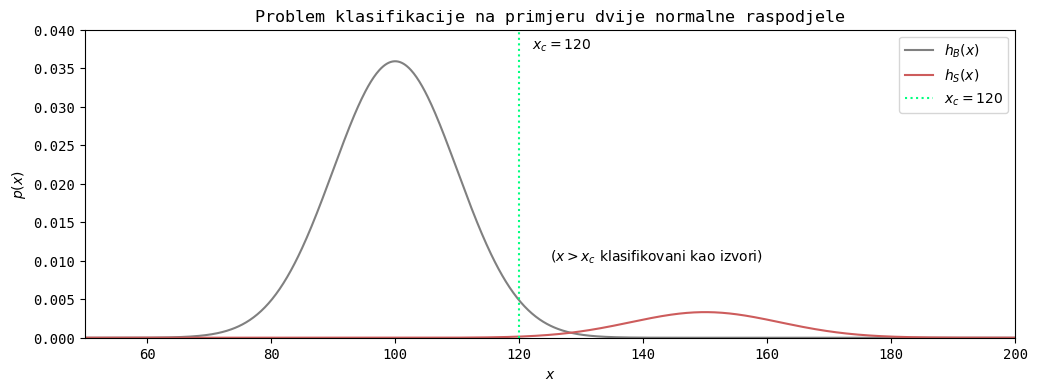

In [5]:
x = np.linspace(50, 200, 1000)
p1 = 0.9 * norm(100, 10).pdf(x)
p2 = 0.1 * norm(150, 12).pdf(x)

plt.figure(figsize=(12, 4))
plt.plot(x, p1, label=r'$h_B(x)$', color='grey')
plt.plot(x, p2, label=r'$h_S(x)$', color='indianred')
plt.plot([120, 120], [0.0, 0.04], ls=':', color='springgreen', label=r'$x_c=120$')
plt.text(122, 0.039, r'$x_c=120$', ha='left', va='top')
plt.text(125, 0.01, r'$(x > x_c\ {\rm klasifikovani\ kao\ izvori})$')
plt.xlim(50, 200)
plt.ylim(0, 0.04)
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.legend()
plt.title(r'Problem klasifikacije na primjeru dvije normalne raspodjele')
plt.show()

Iz rješenja se vidi da je $\epsilon\gg\alpha$. Da bi se smanjio očekivani nivo kontaminacije, treba povećati $x_c$. Međutim, to nije trivijalno, jer $x_c$ zavisi od $a$ (obično nepoznato).

Postoji metoda za odabir optimalne vrijednost $a$ za željeno $\epsilon$ (ili FDR) - tzv. *Benjamini-Hochberg* metoda (zvaćemo je BH metoda). Ona pretpostavlja da se $h(x)$ 

može predstaviti kao suma $h_B(x)$ i $h_S(x)$, gdje figuriše relativni normalizacioni faktor $a$. Takođe, pretpostavlja se da je $h_B(x)$ poznato (npr. $a$ jako malo). Ako

imamo $H_B(x_i)$, onda je moguće pridružiti $p$-vrijednost svakoj vrijednosti u $\{x_i\}$ kao $p_i=1-H_B(x_i)$, i sortirati uzorak tako da $p_i$ raste. Ukoliko $\{x_i\}$ potiče

od $h_B(x)$, raspodjela $p_i$ vrijednosti će biti uniformna, a kumulativna raspodjela, $1\leq C_i\leq N$ će rasti kao $C_i^B=Np_i$. U realnosti pak, $Na$ mjerenja dolazi od

$h_S(x)$ i rezultiraće viškom malih $p_i$ vrijednosti. Zbog toga će izmjerena kumulativna raspodjela $C_i = C(p_i) = i$ imati znatno veće vrijednosti od $C_i^B$ za malo $p$.

BH metoda koristi ovu činjenicu da pronađe prag $p_c$ (i odgovarajući $x_c$, sa indeksom $i_c = C(p_c)$) koji garantuje da je kontaminacija uzorka $\epsilon$ ispod neke željene

vrijednosti $\epsilon_0$. Pretpostavljamo da odbacujemo nultu hipotezu za sve $p_i \leq p_c$, čime dobijamo podskup od $i_c$ vrijednosti klasifikovanih kao izvori. Broj slučajeva

kada je nulta hipoteza bila tačna, a pogrešno odbijena, je $(1-a)Np_c < Np_c$, pa je stopa kontaminacije:

$$\epsilon = \frac{(1-a)Np_c}{i_c} < \frac{Np_c}{i_c}$$

Dakle, uslov koji prag mora zadovoljiti je:

$$i_c < N\frac{p_c}{\epsilon_0} \tag{2}$$

Ovaj uslov odgovara presjeku izmjerene krive $C_i(p_i)$ i prave $C = Np/\epsilon_0$. Algoritam traži najveće $i$ (tj. $C_i$) koje zadovoljava prethodnu jednačinu.

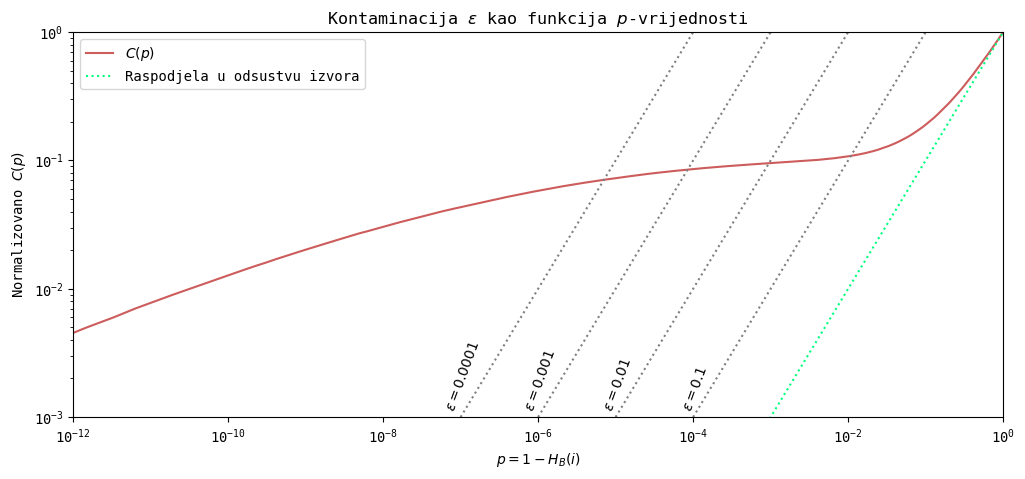

In [6]:
bg = norm(100, 10)
fg = norm(150, 12)
f = 0.1

np.random.seed(42)
N = int(1e6)
X = np.random.random(N)
mask = (X < 0.1)
X[mask] = fg.rvs(np.sum(mask))
X[~mask] = bg.rvs(np.sum(~mask))

p = 1 - bg.cdf(X)
p_sort = np.sort(p)

plt.figure(figsize=(12, 5))
plt.xscale('log')
plt.yscale('log')

plt.plot(p_sort[::1000], np.linspace(0, 1, 1000), label=r'$C(p)$', color='indianred')
plt.plot(p_sort[::1000], p_sort[::1000], label=r'Raspodjela u odsustvu izvora', color='springgreen', ls=':')

p_prim = 10 ** np.linspace(-3, 0, 100)
for epsilon in [0.1, 0.01, 0.001, 0.0001]:
    x = p_prim * epsilon
    y = p_prim
    plt.plot(x, y, color='grey', ls=':')
    plt.text(x[1], y[1], r'$\epsilon = %.1g$' % epsilon, ha='center', va='bottom', rotation=70)

plt.gca().xaxis.set_major_locator(plt.LogLocator(base=100))
plt.xlim(1e-12, 1)
plt.ylim(1e-3, 1)
plt.xlabel(r'$p=1-H_B(i)$')
plt.ylabel(r'Normalizovano $C(p)$')
plt.title(r'Kontaminacija $\epsilon$ kao funkcija $p$-vrijednosti')
plt.legend()
plt.show()

Napomenimo da je $p_c < \epsilon_0$ jer je $i_c < N$; ako bismo uzeli $p_c = \epsilon_0$, dobili bismo kontaminaciju veću od $\epsilon_0$ za faktor $N/i_c$.
BH algoritam je konzervativan jer

pretpostavlja $(1-a) \approx 1$ pri izvođenju gornje granice za $\epsilon$ - stvarna kontaminacija je za faktor $(1-a)$ manja od maksimalno dozvoljene. Ako bismo znali $a$,

mogli bismo povećati $i_c$ za faktor $1/(1-a)$, čime bismo povećali potpunost bez prekoračenja $\epsilon_0$. U slučajevima kada se može pretpostaviti da su velike vr. $p$ 

(npr. $p > 0.5$) dominantno iz nulte hipoteze, kumulativna raspodjela je:

$$C(p_i) = Na + N(1-a)p_i \quad \text{za } p_i > 0.5,$$

sa $C(p_i = 0.5) = C_{0.5}$. Nagib ove prave je $2(N - C_{0.5})$, pa se broj slučajeva kada je nulta hipoteza tačna, a pogrešno odbijena, može procijeniti preko

 $2(N - C_{0.5})p_c$. Ovo je ekvivalentno skaliranju $h_B(x)$ da odgovara izmjerenoj raspodjeli, tj. procjeni $(1-a)$ :

$$
\lambda^{-1} \equiv 1 - a = 2\left(1 - \frac{C_{0.5}}{N}\right).
$$

BH metoda se može poboljšati množenjem $i_c$ sa $\lambda$, čime se potpunost povećava za faktor $\lambda$.

---

Kada raspodjele nisu poznate, testovi se nazivaju *neparametarski* (ili testovi bez pretpostavljene raspodjele). Najpopularniji je **Kolmogorov-Smirnov** (K-S) test, koji poredi kumulativne raspodjele $F(x)$ dva skupa uzoraka, $\{x_{1_i}\}$ i $\{x_{2_i}\}$. K-S statistika mjeri maksimalnu razliku između dvije kumulativne raspodjele $F_1(x_1)$
i $F_2(x_2)$ kao:

$$
D = \max|F_1(x1) - F_2(x2)|,
$$

gdje je $0 \leq D \leq 1$.

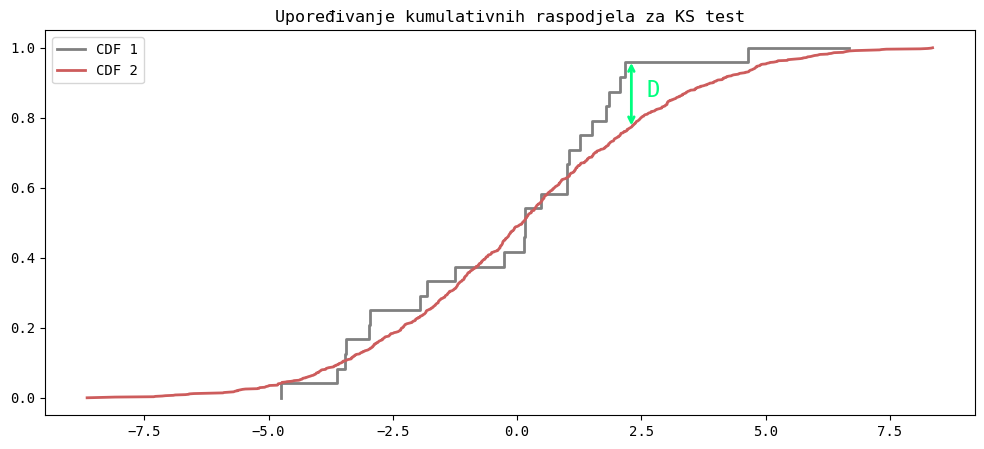

In [7]:
np.random.seed(4)
plt.figure(figsize=(12, 5))

plt.step(np.sort(norm.rvs(0,3,25)), np.linspace(0, 1, 25) , lw=2, color='grey')
plt.plot(np.sort(norm.rvs(0,3,1000)), np.linspace(0, 1, 1000), lw=2, color='indianred')

plt.annotate("", xy=(2.3, 0.965), xytext=(2.3, 0.77), arrowprops=dict(arrowstyle="<->",lw=2, color='springgreen'))
plt.text(2.6,0.86, "D", fontsize = 16, color='springgreen')

plt.legend(['CDF 1', 'CDF 2'])
plt.title('Upoređivanje kumulativnih raspodjela za KS test')
plt.show()

Ključno pitanje je koliko često bi vrijednost $D$ nastala slučajno ako oba uzorka potiču iz *iste* raspodjele (nulta hipoteza). Kolmogorov je 1933. pokazao da je
vjerovatnoća da se dobije $D$ veće od *izračunatog* data preko sljedeće relacije:

$$
Q_{KS}(\lambda) = 2\sum_{k=1}^{\infty}(-1)^{k-1}e^{-2k^2\lambda^2},
$$

gdje je:

$$
\lambda = \left(0.12 + \sqrt{n_e} + \frac{0.11}{\sqrt{n_e}}\right)D, \qquad n_e = \frac{N_1 N_2}{N_1 + N_2}.
$$

Za veliko $n_e$ (broj efektivnih podataka), $\lambda \approx \sqrt{n_e}\, D$. Ako je $Q_{KS}$ malo (npr. $< 0.01$ ili $< 0.05$), odbacuje se nulta hipoteza. Za $n_e \gtrsim 10$, kritična vrijednost $D$ za dati nivo značajnosti $\alpha$ je:

$$
D_{KS} = \frac{C(\alpha)}{\sqrt{n_e}},
$$

gdje je $C(0.05) = 1.36$ i $C(0.01) = 1.63$. *Moć* testa raste sa $\sqrt{n_e}$. Npr. za $n_e = 100$, vrijednost $D > 0.163$ nastaje slučajno u samo 1% slučajeva - može
se odbaciti nulta hipoteza sa tačnošću 99/100.

K-S test se može koristiti i kao *jednouzorački test* - da li izmjereni $f(x)$ potiče od poznate referentne raspodjele $h(x)$? U tom slučaju $N_1 = N$, $N_2 = \infty$, te
$n_e = N$. K-S test je osjetljiv na lokaciju, skalu i oblik raspodjele, i invarijantan na reparametrizaciju $x$ (isti rezultat za $\ln x$ umjesto $x$). Međutim, nije toliko 
osjetljiv na repove raspodjele i na uske osobine diferencijalne raspodjele - nije idealan za razlikovanje normalnih i eksponencijalnih uzoraka.

In [ ]:
np.random.seed(0)
v = np.random.normal(loc=0, scale=1, size= 1000)

print(f'Normalna: {kstest(v, "norm")}')
print(f'Uniformna: {kstest(v, "uniform")}')


np.random.seed(0)
s1 = np.random.uniform(low=0.0, high=1.0,size=100)
s2 = np.random.normal(loc=0.0, scale=1.0,size=110)
s3 = np.random.normal(loc=0.0, scale=1.0,size=95)

print(f'Uniformna vs. Normalna: {ks_2samp(s1, s2)}')
print(f'Normalna vs. Normalna: {ks_2samp(s2, s3)}')

Normalna: KstestResult(statistic=0.03737519429804048, pvalue=0.11930823166569182, statistic_location=0.47224715008784873, statistic_sign=1)
Uniformna: KstestResult(statistic=0.524, pvalue=3.108930667670788e-256, statistic_location=-0.001385042735095726, statistic_sign=1)
Uniformna vs. Normalna: KstestResult(statistic=0.4627272727272727, pvalue=1.1459194722930249e-10, statistic_location=0.01747915902505673, statistic_sign=-1)
Normalna vs. Normalna: KstestResult(statistic=0.1645933014354067, pvalue=0.1099922578927004, statistic_location=0.8235041539637314, statistic_sign=-1)


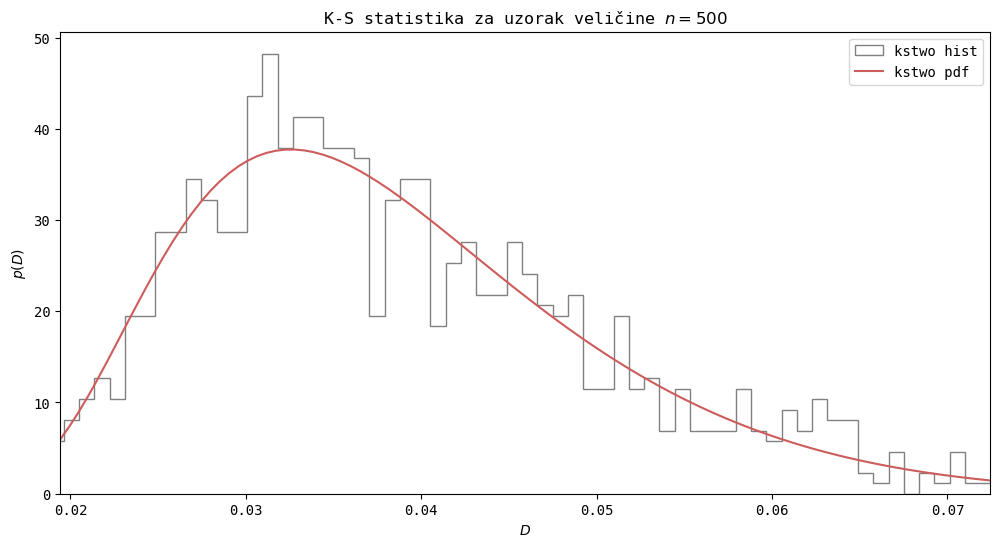

In [11]:
n = 500
r = kstwo.rvs(n, size=1000)

plt.figure(figsize=(12,6))
x = np.linspace(kstwo.ppf(0.01, n), kstwo.ppf(0.99, n), 100)
plt.hist(r, density=True, bins=100, histtype='step', color='grey', label = 'kstwo hist')
plt.plot(x, kstwo.pdf(x, n), color='indianred', label='kstwo pdf')
plt.xlim([x[0], x[-1]])
plt.xlabel(r'$D$')
plt.ylabel(r'$p(D)$')
plt.title(rf'K-S statistika za uzorak veličine $n={n}$')
plt.legend(loc='best')
plt.show()